In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import requests
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.tree import DecisionTreeRegressor
from sklearn.experimental import enable_iterative_imputer
from sklearn.utils import resample
from sklearn.impute import SimpleImputer, IterativeImputer
import warnings
warnings.filterwarnings('ignore')

In [2]:
# Cargar datos
file_path = 'C:/Users/maite/OneDrive - UNIR/tfm/dataset/datos_completos.csv'
data = pd.read_csv(file_path)

### Análisis exploratorio

In [3]:
# Mostrar información general y las primeras filas
print("Información general del dataset:")
data.info()
data.head()

Información general del dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4991 entries, 0 to 4990
Data columns (total 33 columns):
 #   Column                                                                      Non-Null Count  Dtype  
---  ------                                                                      --------------  -----  
 0   CountryName                                                                 4991 non-null   object 
 1   CountryCode                                                                 4991 non-null   object 
 2   Year                                                                        4991 non-null   int64  
 3   Age dependency ratio (% of working-age population)                          4991 non-null   float64
 4   Annual freshwater withdrawals, domestic (% of total freshwater withdrawal)  3604 non-null   float64
 5   GDP per capita (current US$)                                                4785 non-null   float64
 6   Gini index     

,CountryName,CountryCode,Year,Age dependency ratio (% of working-age population),"Annual freshwater withdrawals, domestic (% of total freshwater withdrawal)",GDP per capita (current US$),Gini index,"Hospital beds (per 1,000 people)","Immunization, DPT (% of children ages 12-23 months)","Intentional homicides (per 100,000 people)",...,TD,GS,Drug.use.disorders,Schizophrenia,Eating.disorders,Bipolar.disorder,Depression,Anxiety.disorders,Alcohol.use.disorders,PIB
0,Afghanistan,AFG,2001,108.989886,0.808049,142.903364,NaN,0.39,33.0,NaN,...,7.958,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-10.101966
1,Afghanistan,AFG,2002,109.347157,0.855760,182.174038,NaN,0.39,36.0,NaN,...,7.939,9.443391,NaN,NaN,NaN,NaN,NaN,NaN,NaN,20.567963
2,Afghanistan,AFG,2003,109.447532,0.903386,199.643227,NaN,0.39,41.0,NaN,...,7.922,8.941258,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.927029
3,Afghanistan,AFG,2004,109.286820,0.950928,221.830531,NaN,0.39,50.0,NaN,...,7.914,9.808474,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-2.497255
4,Afghanistan,AFG,2005,107.964605,0.998385,254.115276,NaN,0.42,58.0,NaN,...,7.914,9.948289,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7.321874


Exploramos los campos con valores faltantes.

Muchísimas de la variabels tienen más del 50% de daltos faltantes. Las que tienen poco podrían imputarse. El problema es que muchas de las prevalencias de las enfermedades están vacías. 


Valores faltantes:
Literacy rate, adult total (% of people ages 15 and above)                    0.836706
Prevalence of current tobacco use (% of adults)                               0.804047
Poverty headcount ratio at national poverty lines (% of population)           0.797836
Alcohol.use.disorders                                                         0.727510
Anxiety.disorders                                                             0.727510
Eating.disorders                                                              0.727510
Depression                                                                    0.727510
Schizophrenia                                                                 0.727510
Drug.use.disorders                                                            0.727510
Bipolar.disorder                                                              0.727510
Gini index                                                                    0.684232
Physicians (per 1,000 p

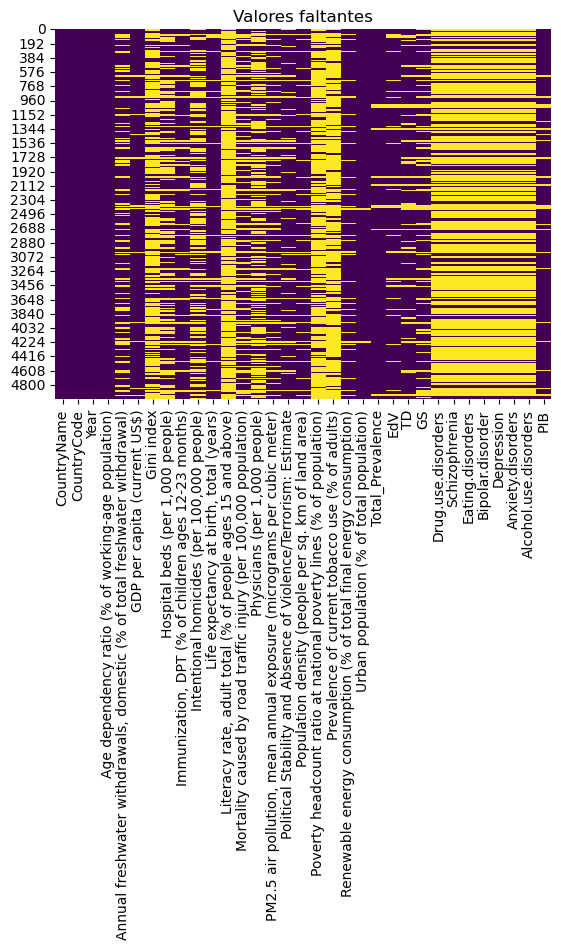

In [4]:
print("\nValores faltantes:")
missing_values = data.isnull().mean().sort_values(ascending=False)
print(missing_values[missing_values > 0])

# Visualizar valores faltantes
sns.heatmap(data.isnull(), cbar=False, cmap='viridis')
plt.title('Valores faltantes')
plt.show()

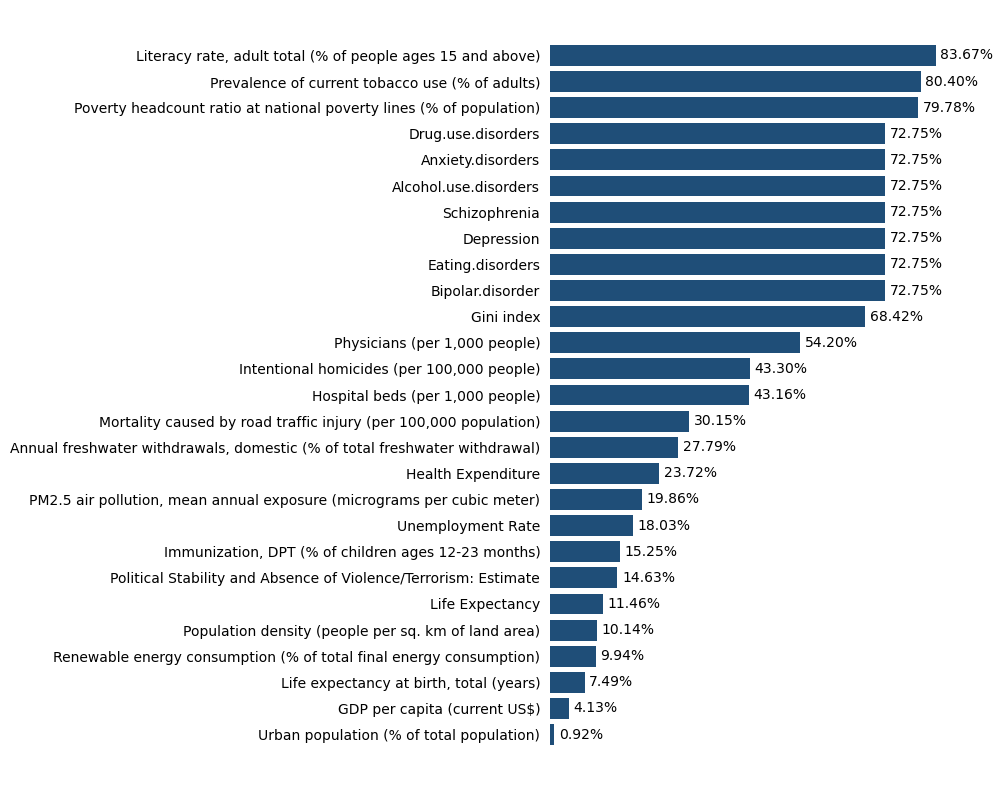

In [5]:
# Calcular el porcentaje de datos faltantes por variable, excluyendo columnas específicas
excluded_columns = ['Total_Prevalence', 'PIB']
data_filtered = data.drop(columns=excluded_columns, errors='ignore')
missing_values = data_filtered.isnull().mean() * 100  # Convertir a porcentaje
missing_values = missing_values[missing_values > 0].sort_values()  # Ordenar de menor a mayor

# Renombrar algunas variables para el gráfico
rename_map = {
    'GS': 'Health Expenditure',
    'EdV': 'Life Expectancy',
    'TD': 'Unemployment Rate'
}
missing_values = missing_values.rename(index=rename_map)

# Crear un DataFrame a partir de los datos faltantes
missing_df = missing_values.reset_index()
missing_df.columns = ['Variable', 'Porcentaje']

# Crear gráfico de barras horizontales
plt.figure(figsize=(10, 8))
plt.barh(missing_df['Variable'], missing_df['Porcentaje'], color='#1f4e78')

# Añadir etiquetas al final de cada barra
for index, value in enumerate(missing_df['Porcentaje']):
    plt.text(value + 1, index, f'{value:.2f}%', va='center', fontsize=10)

# Configurar diseño
#plt.title('Percentage of Missing Data by Variable', fontsize=14, pad=15)
#plt.xlabel('Percentage (%)', fontsize=12)
plt.gca().tick_params(left=False, bottom=False, labelbottom=False)  # Quitar ejes
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.gca().spines['left'].set_visible(False)
plt.gca().spines['bottom'].set_visible(False)
plt.tight_layout()
plt.show()


Añadir el continente con el código de los países, podemos utilizarlo para las visualizaciones y los análisis. 

In [6]:
# Hacer una solicitud a la API de Restcountries para obtener la información de todos los países
response = requests.get('https://restcountries.com/v3.1/all')
countries_data = response.json()

# Crear un diccionario que mapea códigos de tres letras a dos letras y obtiene el continente
three_to_two_letter_map = {}
country_to_continent_map = {}
for country in countries_data:
    if 'cca3' in country and 'cca2' in country and 'region' in country:
        three_to_two_letter_map[country['cca3']] = country['cca2']  # Mapea 3 letras -> 2 letras
        country_to_continent_map[country['cca2']] = country['region']  # Mapea 2 letras -> continente

# Verificar los primeros registros del mapeo
print(list(three_to_two_letter_map.items())[:10])

# Aplicar la conversión de códigos de tres letras a dos letras en tu dataset
data['CountryCode'] = data['CountryCode'].map(three_to_two_letter_map)

# Verificar los primeros registros para asegurarse de que la conversión es correcta
print(data['CountryCode'].head())

# Mapear los continentes utilizando los códigos de dos letras en tu dataset
data['Continent'] = data['CountryCode'].map(country_to_continent_map)

# Verificar que la columna 'Continent' se haya agregado correctamente
print(data[['CountryName', 'CountryCode', 'Continent']].head())

[('SGS', 'GS'), ('GRD', 'GD'), ('CHE', 'CH'), ('SLE', 'SL'), ('HUN', 'HU'), ('TWN', 'TW'), ('WLF', 'WF'), ('BRB', 'BB'), ('PCN', 'PN'), ('CIV', 'CI')]
0    AF
1    AF
2    AF
3    AF
4    AF
Name: CountryCode, dtype: object
   CountryName CountryCode Continent
0  Afghanistan          AF      Asia
1  Afghanistan          AF      Asia
2  Afghanistan          AF      Asia
3  Afghanistan          AF      Asia
4  Afghanistan          AF      Asia


In [ ]:
#data.to_csv('C:/Users/maite/OneDrive - UNIR/tfm/dataset/dataset_contientes.csv', index=False)

En la bbdd hay muchos total_prevalence que son 0 cuando el resto de sus columnas de enfermedades son missings, esto puede llevar a futuros errores. Convierto Total_prevalence en NA cuando todas sus columnas de enfermedades también son NA.

In [7]:
# Lista de variables relevantes para prevalencias
prevalence_cols = ["Alcohol.use.disorders", "Anxiety.disorders", "Eating.disorders", 
                   "Depression", "Schizophrenia", "Drug.use.disorders", "Bipolar.disorder"]

# Asegurarse de que 'Total_Prevalence' sea NA si todas las variables de prevalencia son NA
data['Total_Prevalence'] = data.apply(
    lambda row: np.nan if row[prevalence_cols].isnull().all() else row['Total_Prevalence'],
    axis=1
)

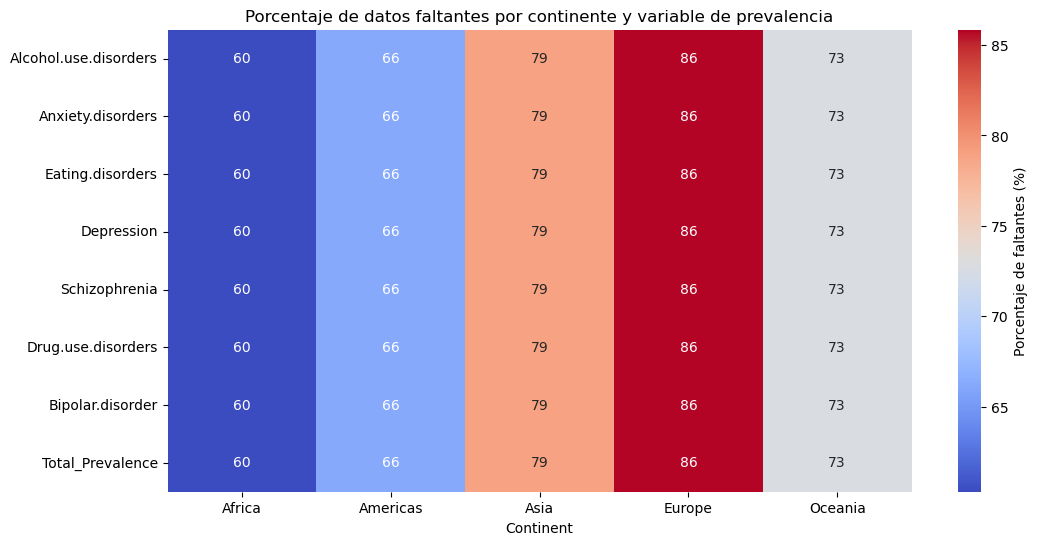

Continent,Africa,Americas,Asia,Europe,Oceania
count,8.000000e+00,8.000000,8.000000e+00,8.000000e+00,8.000000
mean,6.030596e+01,66.257089,7.888199e+01,8.584644e+01,72.768879
std,7.596021e-15,0.000000,1.519204e-14,1.519204e-14,0.000000
min,6.030596e+01,66.257089,7.888199e+01,8.584644e+01,72.768879
25%,6.030596e+01,66.257089,7.888199e+01,8.584644e+01,72.768879
50%,6.030596e+01,66.257089,7.888199e+01,8.584644e+01,72.768879
75%,6.030596e+01,66.257089,7.888199e+01,8.584644e+01,72.768879
max,6.030596e+01,66.257089,7.888199e+01,8.584644e+01,72.768879


In [8]:
# Lista de columnas relevantes para las prevalencias
prevalence_cols = ["Alcohol.use.disorders", "Anxiety.disorders", "Eating.disorders", 
                   "Depression", "Schizophrenia", "Drug.use.disorders", "Bipolar.disorder", "Total_Prevalence"]

# Extraer los datos relevantes: prevalencias, 'CountryName', 'CountryCode' y 'Continent'
prevalence_data = data[["CountryName", "CountryCode", "Continent"] + prevalence_cols]

# Calcular el porcentaje de valores faltantes por continente y por cada columna de prevalencia
missing_percent_by_continent = prevalence_data.groupby('Continent')[prevalence_cols].apply(lambda x: x.isnull().mean() * 100)

# Visualizar los datos faltantes por continente y por columna de prevalencia
plt.figure(figsize=(12, 6))
missing_percent_by_continent = missing_percent_by_continent.T  # Transponer para que las columnas sean las de prevalencia
sns.heatmap(missing_percent_by_continent, annot=True, cmap="coolwarm", cbar_kws={'label': 'Porcentaje de faltantes (%)'})
plt.title("Porcentaje de datos faltantes por continente y variable de prevalencia")
#plt.xlabel("Continente")
#plt.ylabel("Variables de Prevalencia")
plt.show()

# Resumen del porcentaje de datos faltantes por continente y columna
missing_percent_by_continent.describe()

### Comparación del Número de Países por Continente

En este bloque de código, se compara el número de países por continente antes y después de filtrar las filas con valores faltantes en la columna `Total_Prevalence`. 

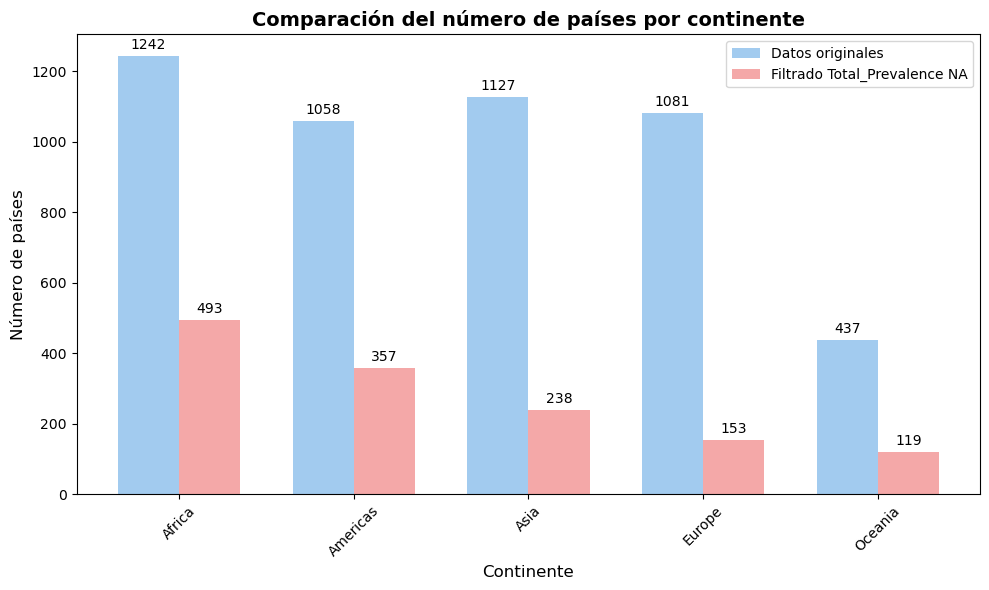

In [9]:
# Contar países por continente con los datos originales
original_counts = data.groupby("Continent")["CountryCode"].count()

# Filtrar filas donde Total_Prevalence es NA
filtered_data = data.dropna(subset=["Total_Prevalence"])

# Contar países por continente después del filtrado
filtered_counts = filtered_data.groupby("Continent")["CountryCode"].count()

# Usar una paleta de colores pastel
colors_original = ['#A2CBEF']  # Azul pastel
colors_filtered = ['#F4A8A8']  # Rojo pastel

# Crear un gráfico de barras lado a lado para comparar
fig, ax = plt.subplots(figsize=(10, 6))
index = original_counts.index.union(filtered_counts.index)  # Asegurar que todos los continentes estén presentes
x = range(len(index))  # Posiciones en el eje X
width = 0.35  # Ancho de las barras

# Dibujar las barras lado a lado con colores personalizados
bars1 = ax.bar(
    [i - width / 2 for i in x], 
    original_counts.reindex(index, fill_value=0), 
    width, 
    label="Datos originales", 
    color=colors_original
)
bars2 = ax.bar(
    [i + width / 2 for i in x], 
    filtered_counts.reindex(index, fill_value=0), 
    width, 
    label="Filtrado Total_Prevalence NA", 
    color=colors_filtered
)

# Mejoras visuales
ax.set_title("Comparación del número de países por continente", fontsize=14, weight="bold")
ax.set_ylabel("Número de países", fontsize=12)
ax.set_xlabel("Continente", fontsize=12)
ax.set_xticks(x)
ax.set_xticklabels(index, rotation=45, fontsize=10)
ax.legend(fontsize=10)

# Añadir etiquetas a las barras
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.annotate(f'{int(height)}', 
                    xy=(bar.get_x() + bar.get_width() / 2, height), 
                    xytext=(0, 3),  # Desplazamiento vertical
                    textcoords="offset points", 
                    ha='center', va='bottom', fontsize=10)

# Ajustar márgenes y mostrar la gráfica
plt.tight_layout()
plt.show()

### Análisis de los Países con Valores Faltantes en `Total_Prevalence`

En este bloque de código, se realiza un análisis para identificar y clasificar los países que tienen valores faltantes (`NA`) en la columna `Total_Prevalence` en diferentes años. 

1. **Agrupar los datos por 'CountryCode' y comprobar si `Total_Prevalence` es NA en todos los años:**

In [10]:
# Agrupar los datos por 'CountryCode' y comprobar si 'Total_Prevalence' es NA en todos los años
na_status_by_country = data.groupby("CountryCode")["Total_Prevalence"].apply(lambda x: x.isnull().all())

# Filtrar los países eliminados (los que tienen Total_Prevalence NA en al menos un año)
countries_with_na = na_status_by_country[na_status_by_country].index

# Analizar los países eliminados
removed_countries = data[data["CountryCode"].isin(countries_with_na)]

# Contar los países con NA en todos los años y en algunos años
completely_na_countries = removed_countries.groupby("CountryCode")["Total_Prevalence"].apply(lambda x: x.isnull().all()).sum()
partially_na_countries = len(countries_with_na) - completely_na_countries

# Resultados
print(f"Total países eliminados: {len(countries_with_na)}")
print(f"Países con Total_Prevalence NA en todos los años: {completely_na_countries}")
print(f"Países con Total_Prevalence NA en algunos años: {partially_na_countries}")


Total países eliminados: 135
Países con Total_Prevalence NA en todos los años: 135
Países con Total_Prevalence NA en algunos años: 0


### Análisis de Países Únicos por Continente Antes y Después de Filtrar los Valores Faltantes

En este bloque de código, comparamos la cantidad de países únicos por continente antes y después de filtrar los países con valores faltantes (`NA`) en la columna `Total_Prevalence`. Este análisis nos ayuda a entender cuántos países se mantienen en el conjunto de datos después de la eliminación de aquellos con valores faltantes en `Total_Prevalence`.


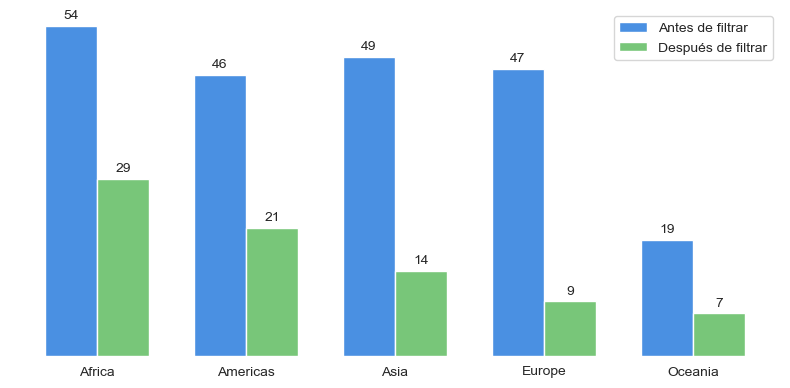

In [16]:
###### Contar países únicos por continente en los datos originales
original_unique_counts = data.drop_duplicates(subset=["CountryCode"])["Continent"].value_counts()

# Contar países únicos por continente después de eliminar filas con Total_Prevalence NA
filtered_unique_data = data.dropna(subset=["Total_Prevalence"]).drop_duplicates(subset=["CountryCode"])
filtered_unique_counts = filtered_unique_data["Continent"].value_counts()

# Estilo de gráficos con Seaborn
sns.set_style("whitegrid")
sns.set_palette("pastel")

# Crear un gráfico de barras lado a lado para comparar
fig, ax = plt.subplots(figsize=(8, 4))
index = original_unique_counts.index.union(filtered_unique_counts.index)  # Asegurar que todos los continentes estén presentes
x = range(len(index))  # Posiciones en el eje X
width = 0.35  # Ancho de las barras

# Dibujar las barras lado a lado con nuevos colores
bars1 = ax.bar([i - width / 2 for i in x],
               original_unique_counts.reindex(index, fill_value=0), width, label="Antes de filtrar", color='#4A90E2')
bars2 = ax.bar([i + width / 2 for i in x],
               filtered_unique_counts.reindex(index, fill_value=0), width, label="Después de filtrar", color="#78C679")

# Mejoras visuales: título y etiquetas de las barras
#ax.set_title("Número de países únicos por continente", fontsize=14, weight="bold")
ax.set_xticks(x)
ax.set_xticklabels(index, rotation=0, fontsize=10)

# Eliminar ejes y cuadrícula
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.spines['bottom'].set_visible(False)
ax.tick_params(left=False, bottom=False, labelleft=False)
ax.grid(False)  # Eliminar el grid

# Cambiar la leyenda
ax.legend(fontsize=10, loc="upper right")

# Añadir etiquetas a las barras
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.annotate(f'{int(height)}', 
                    xy=(bar.get_x() + bar.get_width() / 2, height), 
                    xytext=(0, 3),  # Desplazamiento vertical
                    textcoords="offset points", 
                    ha='center', va='bottom', fontsize=10)

# Ajustar márgenes y mostrar la gráfica
plt.tight_layout()
plt.show()




Calculamos el porcentaje de valores faltantes para cada columna después del filtrado. 


Valores faltantes después de filtrar Total_Prevalence NA:
Prevalence of current tobacco use (% of adults)                               0.847794
Literacy rate, adult total (% of people ages 15 and above)                    0.803676
Poverty headcount ratio at national poverty lines (% of population)           0.780147
Gini index                                                                    0.662500
Physicians (per 1,000 people)                                                 0.489706
Intentional homicides (per 100,000 people)                                    0.361029
Hospital beds (per 1,000 people)                                              0.340441
Annual freshwater withdrawals, domestic (% of total freshwater withdrawal)    0.117647
GS                                                                            0.065441
Political Stability and Absence of Violence/Terrorism: Estimate               0.064706
TD                                                                     

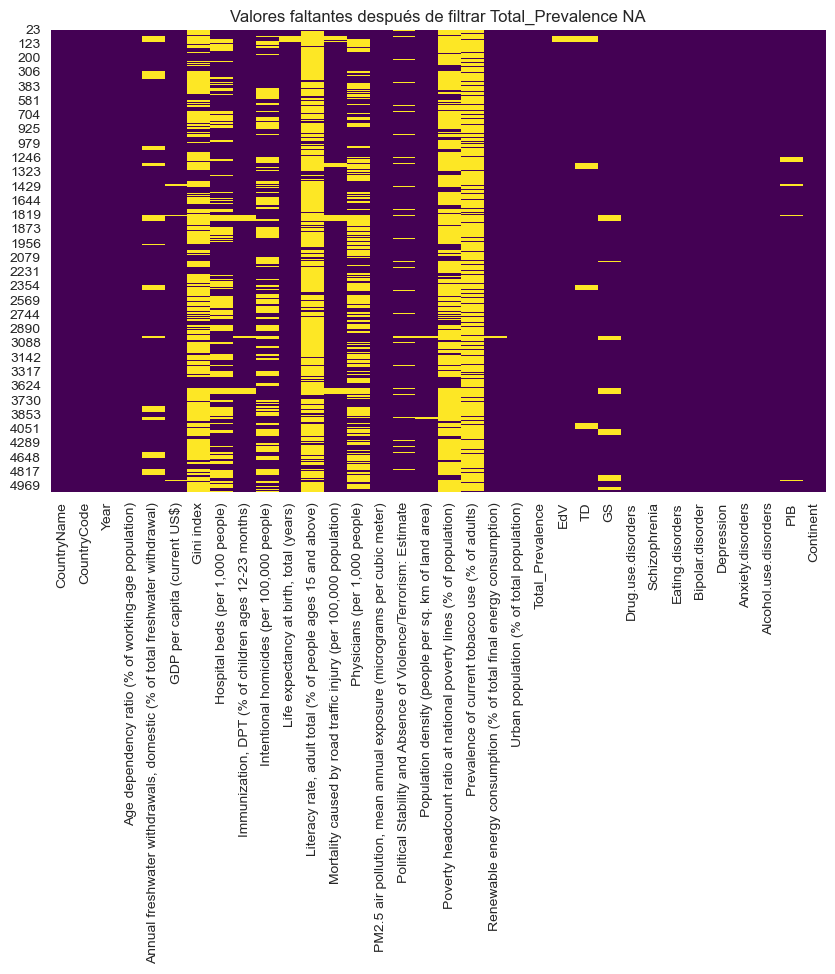

In [17]:
# Filtrar los datos eliminando las filas con 'Total_Prevalence' como NA
filtered_data = data.dropna(subset=["Total_Prevalence"])

# Ver el porcentaje de faltantes por columna después de filtrar
print("\nValores faltantes después de filtrar Total_Prevalence NA:")
missing_values_after_filter = filtered_data.isnull().mean().sort_values(ascending=False)
print(missing_values_after_filter[missing_values_after_filter > 0])

# Visualizar los valores faltantes en el conjunto filtrado
plt.figure(figsize=(10, 6))
sns.heatmap(filtered_data.isnull(), cbar=False, cmap='viridis')
plt.title('Valores faltantes después de filtrar Total_Prevalence NA')
plt.show()

### Imputación de Datos en el Análisis

En este análisis, hemos trabajado con un conjunto de datos que contiene valores faltantes, particularmente en la columna `Total_Prevalence`, lo que puede afectar negativamente el rendimiento de los modelos predictivos. Para abordar este problema, se ha optado por aplicar técnicas de imputación, las cuales permiten rellenar los valores faltantes con estimaciones basadas en los valores observados en el conjunto de datos.

Existen diferentes métodos de imputación, cada uno con sus propias ventajas y aplicaciones dependiendo del tipo de datos y la naturaleza de los valores faltantes. A continuación, se describen los métodos que hemos utilizado para la imputación de los datos en este proyecto:

1. **Predictive Mean Matching (PMM):**
   Este método busca resolver los valores faltantes seleccionando valores candidatos para reemplazar los faltantes. Para cada valor faltante, se forma un grupo de valores candidatos que tienen predicciones cercanas al valor faltante. Se extrae un valor aleatorio de los candidatos y se utiliza para imputar el valor faltante. Este método es útil porque mantiene la distribución original de los datos y asegura que las imputaciones sean razonables dentro del contexto de los valores observados.

   *Ventajas:* PMM mantiene la estructura y la variabilidad de los datos, lo que es esencial cuando se trabaja con variables continuas y distribuciones complejas.

2. **Multiple Imputation with Denoising Autoencoders (MIDAS):**
   MIDAS utiliza redes neuronales para imputar los valores faltantes. Los autoencoders de eliminación de ruido (Denoising Autoencoders, DA) son una clase de redes neuronales no supervisadas que buscan aprender una representación más compacta y útil de los datos. Estos modelos inyectan ruido estocástico en los datos y luego intentan reconstruir la información perdida. Este proceso puede ser especialmente útil cuando se trata de conjuntos de datos con estructuras complejas o patrones no lineales.

   *Ventajas:* MIDAS es útil cuando se trabaja con grandes volúmenes de datos y tiene la capacidad de aprender patrones complejos y no lineales en los datos faltantes.

3. **Classification and Regression Trees (CART):**
   CART es un modelo predictivo basado en árboles de decisión que divide los datos en subgrupos homogéneos mediante la segmentación recursiva. Para imputar un valor faltante, CART utiliza las características de las observaciones disponibles y predice el valor faltante en función de los valores observados en el resto de las variables. Este método es eficaz para datos que tienen relaciones no lineales o interacciones entre variables.

   *Ventajas:* CART es una técnica interpretable que puede manejar tanto variables continuas como categóricas y es robusta a relaciones no lineales.

4. **Random Forest (RF):**
   Random Forest es una extensión del modelo de árboles de decisión (CART) que utiliza múltiples árboles de decisión (un conjunto de árboles) para mejorar la precisión de las predicciones. Al agregar múltiples árboles a través de un proceso conocido como "bootstrap aggregation" o bagging, RF reduce el riesgo de sobreajuste (overfitting) y mejora la estabilidad y precisión del modelo. Este enfoque es adecuado cuando se trata de grandes cantidades de datos con alta varianza.

   *Ventajas:* RF es robusto a la sobreajuste, eficaz para manejar grandes volúmenes de datos y útil para capturar relaciones complejas entre variables.

5. **Sample Random Sampling (SRS):**
   Sample Random Sampling consiste en seleccionar aleatoriamente valores del conjunto de datos y asignarlos a las observaciones faltantes. Este método mantiene la distribución original de los datos y es útil cuando no se dispone de información suficiente para aplicar otros métodos más complejos. La imputación aleatoria es rápida, pero puede no ser tan precisa como otros métodos más sofisticados.

   *Ventajas:* SRS es fácil de implementar y útil cuando no se dispone de un modelo predictivo adecuado o cuando los valores faltantes no siguen patrones complejos.

---

#### ¿Por qué es importante realizar imputaciones?

Las imputaciones son esenciales porque los valores faltantes pueden sesgar los análisis, reducir el tamaño de la muestra y, en general, afectar la calidad de los modelos predictivos. Al imputar los datos faltantes, se mejora la integridad del conjunto de datos y se asegura que los modelos puedan aprender de la totalidad de las observaciones, lo que permite realizar predicciones más precisas y generalizables. Además, algunas técnicas de imputación, como las mencionadas, no solo rellenan los valores faltantes, sino que también pueden incorporar la variabilidad y complejidad de los datos originales, lo que mejora la robustez del análisis.

---

#### Recomendaciones Generales para Imputación de Datos Faltantes:

1. **Menos del 5% de datos faltantes**:
   - Si la columna tiene menos del 5% de valores faltantes, generalmente no es problemático hacer imputaciones. Puedes usar métodos de imputación como la media, mediana, moda o incluso modelos predictivos si es adecuado.

2. **Entre el 5% y el 20% de datos faltantes**:
   - Entre el 5% y el 20%, aún puedes imputar los valores faltantes, pero deberías ser más cuidadoso. Si los datos son continuos, la imputación mediante la media o mediana puede ser adecuada. Para datos categóricos, la imputación con la moda puede funcionar bien.
   - También puedes considerar métodos de imputación más avanzados, como la imputación por k-vecinos más cercanos (KNN) o modelos de regresión.

3. **Más del 20% de datos faltantes**:
   - Si más del 20% de los datos están faltando en una columna, la imputación puede no ser confiable. En estos casos, el modelo de imputación podría no ser preciso y las inferencias podrían estar sesgadas. Una posible estrategia sería **eliminar** la columna si no aporta suficiente información, o si es crítica para el análisis, tal vez explorar imputaciones más complejas (como técnicas de Machine Learning).
   
4. **Más del 50% de datos faltantes**:
   - Con más del 50% de valores faltantes en una columna, la imputación ya no es recomendable, ya que los resultados probablemente serán poco confiables. En este caso, es preferible eliminar la columna, si es posible, o considerar usar técnicas específicas que puedan manejar grandes cantidades de datos faltantes, como la imputación múltiple o el uso de modelos predictivos.

In [18]:
# Filtrar las columnas con más del 20% de valores faltantes
threshold = 0.20
missing_values_after_filter = filtered_data.isnull().mean()
columns_to_remove = missing_values_after_filter[missing_values_after_filter > threshold].index
filtered_data_cleaned = filtered_data.drop(columns=columns_to_remove)

# Seleccionar solo las columnas numéricas que necesitamos imputar (excluyendo CountryName, CountryCode, y Continent)
columns_to_impute = filtered_data_cleaned.select_dtypes(include=[np.number]).columns
columns_to_impute = [col for col in columns_to_impute if col not in ['CountryName', 'CountryCode', 'Continent']]

# Imputación con PMM (Predictive Mean Matching)
def pmm_impute(data, column):
    pmm_imputer = IterativeImputer(random_state=42, max_iter=10, n_nearest_features=3)
    data_imputed = data.copy()
    data_imputed[column] = pmm_imputer.fit_transform(data[[column]])
    return data_imputed

# Imputación con MIDAS (Multiple Imputation with Denoising Autoencoders)
def midas_impute(data, column):
    midas_imputer = IterativeImputer(random_state=42)
    data_imputed = data.copy()
    data_imputed[column] = midas_imputer.fit_transform(data[[column]])
    return data_imputed

# Imputación con CART (Classification and Regression Trees)
def cart_impute(data, column):
    cart_imputer = DecisionTreeRegressor(random_state=42)
    data_imputed = data.copy()
    
    # Eliminar filas con valores faltantes en la columna
    train_data = data.dropna(subset=[column])  # Filtrar datos con valores completos en la columna
    if train_data.shape[0] < 1:  # Verificar si hay suficientes datos para entrenar el modelo
        print(f"No hay suficientes datos para entrenar el modelo en la columna: {column}")
        return data_imputed  # Retorna los datos sin modificar si no hay datos suficientes
    
    # Características y etiquetas para el entrenamiento
    X_train = train_data.drop(columns=['CountryName', 'CountryCode', 'Continent', column])  # Características
    y_train = train_data[column]  # Etiqueta (valores que queremos predecir)

    # Ajustar el modelo
    cart_imputer.fit(X_train, y_train)
    
    # Predecir los valores faltantes en la columna
    missing_data = data[data[column].isnull()]  # Filtrar los datos faltantes
    X_missing = missing_data.drop(columns=['CountryName', 'CountryCode', 'Continent', column])  # Características para predicción
    
    if X_missing.shape[0] > 0:  # Asegurarse de que haya datos faltantes para predecir
        # Realizar la predicción para los valores faltantes
        data_imputed.loc[missing_data.index, column] = cart_imputer.predict(X_missing)
    
    return data_imputed

# Imputación con Random Forest
def rf_impute(data, column):
    rf_imputer = RandomForestRegressor(random_state=42)
    data_imputed = data.copy()
    
    # Eliminar filas con valores faltantes en la columna
    train_data = data.dropna(subset=[column])  # Filtrar datos con valores completos en la columna
    if train_data.shape[0] < 1:  # Verificar si hay suficientes datos para entrenar el modelo
        print(f"No hay suficientes datos para entrenar el modelo en la columna: {column}")
        return data_imputed  # Retorna los datos sin modificar si no hay datos suficientes
    
    # Características y etiquetas para el entrenamiento
    X_train = train_data.drop(columns=['CountryName', 'CountryCode', 'Continent', column])  # Características
    y_train = train_data[column]  # Etiqueta (valores que queremos predecir)

    # Ajustar el modelo
    rf_imputer.fit(X_train, y_train)
    
    # Predecir los valores faltantes en la columna
    missing_data = data[data[column].isnull()]  # Filtrar los datos faltantes
    X_missing = missing_data.drop(columns=['CountryName', 'CountryCode', 'Continent', column])  # Características para predicción
    
    if X_missing.shape[0] > 0:  # Asegurarse de que haya datos faltantes para predecir
        # Realizar la predicción para los valores faltantes
        data_imputed.loc[missing_data.index, column] = rf_imputer.predict(X_missing)
    
    return data_imputed

# Imputación con Sample Random Sampling
def srs_impute(data, column):
    data_imputed = data.copy()
    
    # Verificar si hay datos faltantes en la columna
    missing_data = data[data[column].isnull()]
    
    if missing_data.shape[0] > 0:  # Solo aplicar si hay valores faltantes
        non_missing_data = data[~data[column].isnull()]
        
        # Resample non-missing data to match missing data count
        resampled_data = resample(non_missing_data, n_samples=len(missing_data), random_state=42)
        data_imputed[column].loc[missing_data.index] = resampled_data[column].values
    #else:
        #print(f"No se encontró ningún valor faltante en la columna: {column}")
    
    return data_imputed

# Imputaciones para cada columna en columns_to_impute
filtered_data_imputed_pmm = filtered_data_cleaned.copy()
filtered_data_imputed_midas = filtered_data_cleaned.copy()
filtered_data_imputed_cart = filtered_data_cleaned.copy()
filtered_data_imputed_rf = filtered_data_cleaned.copy()
filtered_data_imputed_srs = filtered_data_cleaned.copy()

for col in columns_to_impute:
    filtered_data_imputed_pmm = pmm_impute(filtered_data_imputed_pmm, col)
    filtered_data_imputed_midas = midas_impute(filtered_data_imputed_midas, col)
    filtered_data_imputed_cart = cart_impute(filtered_data_imputed_cart, col)
    filtered_data_imputed_rf = rf_impute(filtered_data_imputed_rf, col)
    filtered_data_imputed_srs = srs_impute(filtered_data_imputed_srs, col)

### Explicación del Código de Imputación de Datos

Este código realiza un proceso de imputación de datos en un conjunto filtrado (`filtered_data`) para reemplazar los valores faltantes en varias columnas. El proceso de imputación se lleva a cabo utilizando diferentes métodos, y el código está estructurado de la siguiente manera:

#### 1. **Filtrar las columnas con más del 20% de valores faltantes**:
   - **`threshold = 0.20`**: Se establece un umbral del 20% para eliminar las columnas que tengan más del 20% de valores faltantes.
   - **`missing_values_after_filter = filtered_data.isnull().mean()`**: Calcula el porcentaje de valores faltantes para cada columna del conjunto de datos filtrado.
   - **`columns_to_remove = missing_values_after_filter[missing_values_after_filter > threshold].index`**: Identifica las columnas que tienen más del 20% de valores faltantes.
   - **`filtered_data_cleaned = filtered_data.drop(columns=columns_to_remove)`**: Elimina las columnas con demasiados valores faltantes.

#### 2. **Seleccionar columnas numéricas que necesitan imputación**:
   - **`columns_to_impute = filtered_data_cleaned.select_dtypes(include=[np.number]).columns`**: Filtra las columnas numéricas del conjunto de datos limpio.
   - **`columns_to_impute = [col for col in columns_to_impute if col not in ['CountryName', 'CountryCode', 'Continent']]`**: Excluye columnas no numéricas como `CountryName`, `CountryCode`, y `Continent` que no requieren imputación.

#### 3. **Definición de funciones de imputación**:
   Se definen funciones para cada uno de los cinco métodos de imputación que se utilizarán:

   - **`pmm_impute`** (Predictive Mean Matching): Utiliza el modelo `IterativeImputer` para realizar imputaciones basadas en la predicción de valores cercanos a los observados.
   - **`midas_impute`** (Multiple Imputation with Denoising Autoencoders): Utiliza el modelo `IterativeImputer` para imputaciones, aplicando autoencoders de eliminación de ruido.
   - **`cart_impute`** (Classification and Regression Trees): Usa el modelo `DecisionTreeRegressor` para predecir los valores faltantes basados en las características observadas.
   - **`rf_impute`** (Random Forest): Usa el modelo `RandomForestRegressor` para imputar valores faltantes a partir de un conjunto de árboles de decisión.
   - **`srs_impute`** (Sample Random Sampling): Realiza una imputación aleatoria basada en la muestra de datos disponibles (resampling), manteniendo la distribución original.

#### 4. **Imputación para cada columna**:
   - Se crea una copia del conjunto de datos limpio para cada uno de los métodos de imputación (`filtered_data_imputed_pmm`, `filtered_data_imputed_midas`, etc.).
   - Un ciclo `for` recorre cada columna seleccionada para imputar (`columns_to_impute`).
     - Para cada columna, se aplica cada una de las funciones de imputación (PMM, MIDAS, CART, RF y SRS) y se actualiza el conjunto de datos correspondiente con los valores imputados.
   
#### 5. **Resultado final**:
   Al finalizar el ciclo, cada conjunto de datos (`filtered_data_imputed_pmm`, `filtered_data_imputed_midas`, `filtered_data_imputed_cart`, `filtered_data_imputed_rf`, `filtered_data_imputed_srs`) tendrá los valores faltantes imputados usando diferentes métodos, lo que permite compararlos y evaluar cuál es el más adecuado para el análisis.

En resumen, este código es un proceso de imputación de datos para completar los valores faltantes en el conjunto de datos filtrado, utilizando múltiples enfoques de imputación (PMM, MIDAS, CART, RF, y SRS). Esto asegura que los datos estén completos y listos para ser utilizados en modelos predictivos u otros análisis.


### Explicación de las Gráficas de Densidad

Las gráficas de densidad, generadas mediante el uso de `sns.kdeplot`, muestran la distribución de los datos a través de una curva suave, también conocida como estimación de densidad de Kernel (KDE, por sus siglas en inglés). Estas curvas permiten visualizar cómo se distribuyen los valores de una variable en particular, y ayudan a identificar patrones, sesgos, picos y dispersión en los datos.

#### 1. Ejes de la Gráfica
El **eje X** representa los valores de la variable de interés, es decir, los valores numéricos de la columna que estás analizando. El **eje Y** muestra la densidad, que es una medida de cuán probable es observar un valor en un rango determinado. Cuanto más alta es la densidad en un punto, más probable es encontrar ese valor en los datos.

#### 2. Curvas de Densidad
En cada subgráfico se dibujan varias curvas que representan la distribución de una columna para los datos originales y para los valores imputados con los diferentes métodos de imputación. Los colores de las curvas son los siguientes:
- **Original** (en azul): Muestra la distribución de la columna con los valores originales (sin imputación).
- **PMM Imputado** (en rojo): Muestra la distribución de la columna después de aplicar imputación con el método de Predictive Mean Matching (PMM).
- **MIDAS Imputado** (en verde): Muestra la distribución de la columna después de aplicar imputación con el método de Multiple Imputation with Denoising Autoencoders (MIDAS).
- **CART Imputado** (en morado): Muestra la distribución de la columna después de aplicar imputación con el método de Classification and Regression Trees (CART).
- **RF Imputado** (en naranja): Muestra la distribución de la columna después de aplicar imputación con el método de Random Forest (RF).
- **SRS Imputado** (en negro): Muestra la distribución de la columna después de aplicar imputación con el método de Sample Random Sampling (SRS).

#### 3. Interpretación de las Gráficas
La forma de la curva ayuda a entender cómo se distribuyen los valores en los datos. Si la curva es sesgada hacia la izquierda o la derecha, indica que la mayoría de los valores se concentran en un extremo. Al comparar las distribuciones, se puede evaluar la efectividad de los métodos de imputación.

**Distribución de los Datos Originales**: La curva azul representa la distribución de la variable con los valores originales. Al observar esta curva, puedes ver cómo se distribuyen los datos antes de cualquier imputación, lo cual te permite identificar posibles sesgos, picos o dispersión en los datos.

**Distribución de los Datos Imputados**: Las curvas de los métodos de imputación (PMM, MIDAS, CART, RF, SRS) deben compararse con la curva original. Si las distribuciones de los valores imputados son similares a las de los datos originales, eso indica que el método de imputación ha replicado correctamente la distribución original. Si las distribuciones de los datos imputados son significativamente diferentes, puede ser una señal de que el método de imputación no es adecuado para esa variable.

#### 4. Desajustes entre las Curvas
Si las distribuciones de los datos imputados (especialmente con métodos como MIDAS, CART, RF, etc.) son muy diferentes a la original, esto puede sugerir que esos métodos no están capturando adecuadamente la variabilidad de los datos. Si las imputaciones difieren considerablemente de la distribución original, los datos imputados podrían no reflejar correctamente la variabilidad de los datos, lo que afectaría la calidad del análisis posterior.

#### 5. ¿Qué Esperar?
Los métodos de imputación efectivos deberían producir distribuciones de los valores imputados que sean muy similares a la distribución original. Esto significa que los valores imputados deben tener una forma parecida a los valores reales de los datos. Si las distribuciones imputadas se alejan demasiado de la original, podría ser necesario revisar los métodos de imputación y ajustarlos.

#### 6. Conclusión
Las gráficas de densidad te permiten visualizar la efectividad de los diferentes métodos de imputación en comparación con los datos originales. Al observar cómo las distribuciones de los valores imputados se ajustan a la original, puedes seleccionar el método de imputación que mejor preserve las características de los datos, asegurando que las imputaciones no introduzcan sesgos o distorsiones en los análisis posteriores.


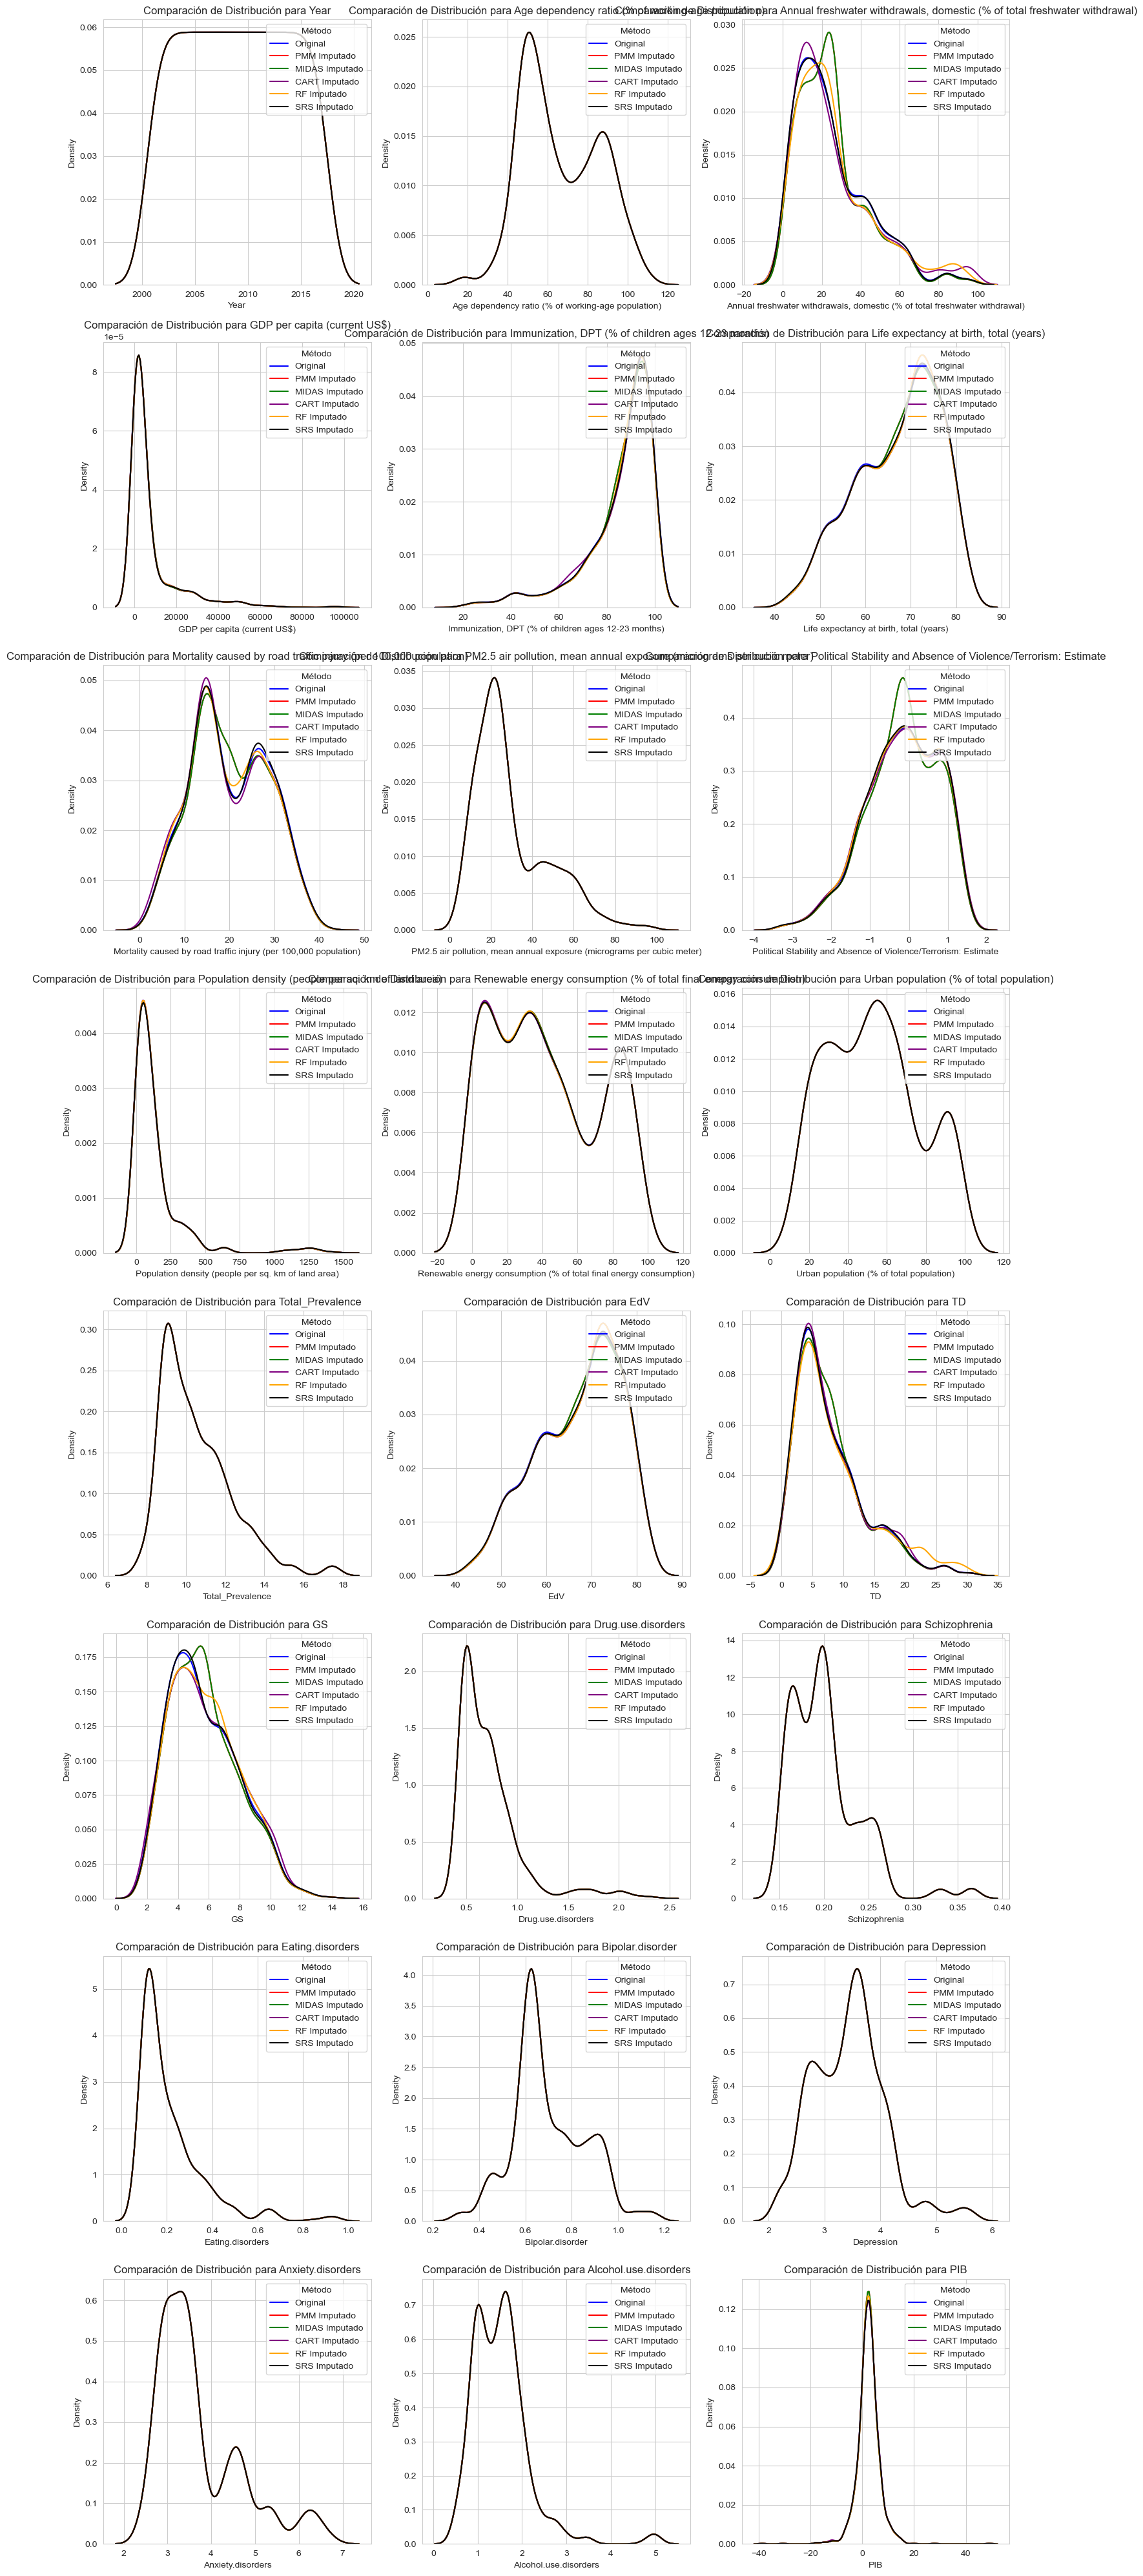

In [19]:
# Crear una matriz de subgráficas de 3 columnas
n_cols = 3
n_rows = int(len(columns_to_impute) / n_cols)   # Número de filas, redondeado hacia arriba

# Crear el gráfico para cada columna
fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 5 * n_rows))
axes = axes.flatten()  # Para facilitar el acceso a cada subgráfico

for i, col in enumerate(columns_to_impute):
    ax = axes[i]
    
    # Graficar las distribuciones de los métodos de imputación sin etiquetas de variable
    sns.kdeplot(filtered_data_cleaned[col], label='Original', fill=False, color='blue', ax=ax)
    sns.kdeplot(filtered_data_imputed_pmm[col], label='PMM Imputado', fill=False, color='red', ax=ax)
    sns.kdeplot(filtered_data_imputed_midas[col], label='MIDAS Imputado', fill=False, color='green', ax=ax)
    sns.kdeplot(filtered_data_imputed_cart[col], label='CART Imputado', fill=False, color='purple', ax=ax)
    sns.kdeplot(filtered_data_imputed_rf[col], label='RF Imputado', fill=False, color='orange', ax=ax)
    sns.kdeplot(filtered_data_imputed_srs[col], label='SRS Imputado', fill=False, color='black', ax=ax)
    
    # Ajustar título y leyenda
    ax.set_title(f'Comparación de Distribución para {col}')
    ax.legend(title='Método', loc='upper right')

# Ajustar los espacios entre subgráficas
plt.tight_layout()
plt.show()

### Evaluación de los Métodos de Imputación con RMSE

El código tiene como objetivo evaluar diferentes métodos de imputación de datos utilizando el **Root Mean Squared Error** (RMSE), una métrica que mide la precisión de las predicciones. En este caso, el RMSE se usa para evaluar qué tan bien cada método de imputación puede aproximarse a los valores reales de las columnas con datos faltantes. Cuanto menor es el RMSE, mejor es el desempeño del método de imputación.

La función `evaluate_imputation_method` toma un conjunto de datos, una columna con valores faltantes, un imputador (como `SimpleImputer`, `IterativeImputer` o modelos como `DecisionTreeRegressor` y `RandomForestRegressor`), y evalúa su efectividad imputando los valores faltantes y luego entrenando un modelo de regresión para predecir los valores imputados. El RMSE se calcula comparando las predicciones del modelo con los valores reales en un conjunto de prueba.

Se evalúan cinco métodos de imputación: 
- **SimpleImputer (media)**, que reemplaza los valores faltantes con el valor medio de la columna.
- **IterativeImputer**, que utiliza un enfoque iterativo para imputar valores.
- **DecisionTreeRegressor (CART)**, que emplea un árbol de decisión para predecir los valores faltantes.
- **RandomForestRegressor (RF)**, que utiliza un bosque aleatorio para la imputación.
- **Sample Random Sampling (SRS)**, que hace un muestreo aleatorio de los datos existentes para imputar los valores faltantes.

Al finalizar la evaluación, se crea un DataFrame con los resultados de RMSE para cada columna y cada método. En la tabla, el método con el mejor desempeño (el que tiene el menor RMSE) se resalta en verde, lo que facilita la selección del mejor método de imputación para cada variable.



In [20]:
# Evaluación de los métodos de imputación (comparando RMSE)
def evaluate_imputation_method(df, column, imputer, method_name, model=None):
    df_copy = df.copy()
    
    # Si el imputador es SimpleImputer o IterativeImputer, utilizamos fit_transform
    if isinstance(imputer, SimpleImputer) or isinstance(imputer, IterativeImputer):
        df_copy[column] = imputer.fit_transform(df_copy[[column]])
    else:
        # Si el imputador es un modelo (DecisionTreeRegressor, RandomForestRegressor, etc.)
        # Dividimos los datos en los registros con y sin valores faltantes
        train_data = df_copy.dropna(subset=[column])  # Datos completos (sin NaN)
        
        if train_data.shape[0] == 0:
            # Si no hay datos completos para entrenar, no realizar imputación
            #print(f"No hay datos completos para entrenar el modelo en la columna {column}.")
            return np.nan
        
        X_train = train_data.drop(columns=['CountryName', 'CountryCode', 'Continent', column])  # Características
        y_train = train_data[column]  # Variable objetivo (columna que se va a imputar)
        
        # Ajustamos el modelo solo con los datos completos
        imputer.fit(X_train, y_train)
        
        # Ahora imputamos los valores faltantes en los datos
        missing_data = df_copy[df_copy[column].isnull()]  # Filtramos los datos faltantes
        X_missing = missing_data.drop(columns=['CountryName', 'CountryCode', 'Continent', column])  # Características de los valores faltantes
        
        if X_missing.shape[0] > 0:
            # Imputamos solo si hay datos faltantes
            y_pred = imputer.predict(X_missing)  # Imputamos los valores faltantes
            df_copy.loc[df_copy[column].isnull(), column] = y_pred
        #else:
            #print(f"No hay valores faltantes en la columna {column} para imputar.")
    
    # Dividir en entrenamiento y prueba
    X = df_copy.dropna(subset=[column]).drop(columns=['CountryName', 'CountryCode', 'Continent'])
    y = df_copy[column].dropna()
    
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
    
    if model is None:  # Si no se pasa un modelo, usamos el modelo predeterminado (RandomForestRegressor)
        model = RandomForestRegressor(random_state=42)
        
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    
    #print(f"RMSE para el método {method_name} en la variable {column}: {rmse:.4f}")
    return rmse

# Crear un diccionario para almacenar los RMSE de cada método por variable
rmse_results = {}

# Evaluar los métodos de imputación para cada columna
for col in columns_to_impute:
    rmse_results[col] = {}
    
    # Evaluar imputación con SimpleImputer
    simple_imputer = SimpleImputer(strategy='mean')
    rmse_simple = evaluate_imputation_method(filtered_data_cleaned, col, simple_imputer, 'SimpleImputer (mean)')
    rmse_results[col]['SimpleImputer (mean)'] = rmse_simple
    
    # Evaluar imputación con IterativeImputer
    iterative_imputer = IterativeImputer(random_state=42)
    rmse_iterative = evaluate_imputation_method(filtered_data_cleaned, col, iterative_imputer, 'IterativeImputer')
    rmse_results[col]['IterativeImputer'] = rmse_iterative
    
    # Evaluar imputación con DecisionTreeRegressor (CART)
    cart_imputer = DecisionTreeRegressor(random_state=42)
    rmse_cart = evaluate_imputation_method(filtered_data_cleaned, col, cart_imputer, 'CART Imputer', model=cart_imputer)
    rmse_results[col]['CART Imputer'] = rmse_cart
    
    # Evaluar imputación con RandomForestRegressor
    rf_imputer = RandomForestRegressor(random_state=42)
    rmse_rf = evaluate_imputation_method(filtered_data_cleaned, col, rf_imputer, 'RF Imputer', model=rf_imputer)
    rmse_results[col]['RF Imputer'] = rmse_rf
    
    # Evaluar imputación con Sample Random Sampling
    srs_imputer = srs_impute(filtered_data_cleaned, col)  # Asumimos que esta es la función ya definida
    rmse_srs = evaluate_imputation_method(srs_imputer, col, SimpleImputer(strategy='mean'), 'SRS Imputer')
    rmse_results[col]['SRS Imputer'] = rmse_srs

# Convertir los resultados a un DataFrame y transponerlo
rmse_df = pd.DataFrame(rmse_results).T  # Usamos .T para transponer y hacer las variables filas y métodos columnas

# Seleccionar el mejor método (el que tenga el menor RMSE) para cada columna
best_methods = rmse_df.idxmin(axis=1)  # Esto obtiene el índice (método) con el RMSE más bajo para cada columna

# Resaltar el mejor método para cada variable comparando directamente los valores de RMSE
def highlight_best_method(s):
    is_best = s == s.min()
    return ['background-color: #A8D5BA' if v else '' for v in is_best]

# Aplicar el resaltado
rmse_df_styled = rmse_df.style.apply(highlight_best_method, axis=1)

# Mostrar la tabla con el resaltado
rmse_df_styled


,SimpleImputer (mean),IterativeImputer,CART Imputer,RF Imputer,SRS Imputer
Year,0.000000,0.000000,0.000000,0.000000,0.000000
Age dependency ratio (% of working-age population),0.183793,0.183793,0.279689,0.183793,0.183793
"Annual freshwater withdrawals, domestic (% of total freshwater withdrawal)",0.154543,0.154543,0.268612,0.131701,0.134436
GDP per capita (current US$),352.187038,352.187038,449.417898,392.815759,362.801847
"Immunization, DPT (% of children ages 12-23 months)",0.362604,0.362604,0.514496,0.359692,0.332887
"Life expectancy at birth, total (years)",0.158513,0.158513,0.152967,0.158741,0.875281
"Mortality caused by road traffic injury (per 100,000 population)",0.206533,0.206533,0.210566,0.202985,0.212678
"PM2.5 air pollution, mean annual exposure (micrograms per cubic meter)",0.628447,0.628447,0.231671,0.628447,0.628447
Political Stability and Absence of Violence/Terrorism: Estimate,0.011859,0.011859,0.011068,0.012441,0.010184
Population density (people per sq. km of land area),2.175764,2.175764,7.021380,2.317747,2.450677


In [ ]:
# Imputar las columnas con el mejor método
filtered_data_final_imputed = filtered_data_cleaned.copy()

for col in columns_to_impute:
    best_method = best_methods[col]  # Obtener el mejor método para esta columna
    
    if best_method == 'SimpleImputer (mean)':
        simple_imputer = SimpleImputer(strategy='mean')
        filtered_data_final_imputed[col] = simple_imputer.fit_transform(filtered_data_final_imputed[[col]])
        
    elif best_method == 'IterativeImputer':
        iterative_imputer = IterativeImputer(random_state=42)
        filtered_data_final_imputed[col] = iterative_imputer.fit_transform(filtered_data_final_imputed[[col]])
        
    elif best_method == 'CART Imputer':
        cart_imputer = DecisionTreeRegressor(random_state=42)
        filtered_data_final_imputed[col] = cart_imputer.fit(filtered_data_final_imputed.dropna(subset=[col]).drop(columns=['CountryName', 'CountryCode', 'Continent'])[[col]],
                                                            filtered_data_final_imputed.dropna(subset=[col])[col]).predict(filtered_data_final_imputed[[col]])
        
    elif best_method == 'RF Imputer':
        rf_imputer = RandomForestRegressor(random_state=42)
        filtered_data_final_imputed[col] = rf_imputer.fit(filtered_data_final_imputed.dropna(subset=[col]).drop(columns=['CountryName', 'CountryCode', 'Continent'])[[col]],
                                                           filtered_data_final_imputed.dropna(subset=[col])[col]).predict(filtered_data_final_imputed[[col]])
    
    elif best_method == 'SRS Imputer':
        filtered_data_final_imputed = srs_impute(filtered_data_final_imputed, col)

# Ahora filtered_data_final_imputed es el dataset con las imputaciones finales


In [ ]:
print(filtered_data_final_imputed.isna().sum())  # Verifica si aún quedan NaN

In [ ]:
filtered_data_final_imputed.to_csv('C:/Users/maite/OneDrive - UNIR/tfm/dataset/dataset_imputaciones.csv', index=False)